### Otimização de Custos de Plano de Saúde

Uma empresa do ramo alimentício tem mais de 20 mil colaboradores em todo o Brasil. Com o passar dos anos a empresa percebeu um aumento no custo do plano de saúde com seus colaboradores. Como forma de entender esse comportamento, a gerência de Benefícios e Bem Estar da Diretoria de Pessoas conduziu uma pesquisa interna com um grupo de 1.338 colaboradores sorteados aleatoriamente.
A gerência acredita que fatores como fumo e obesidade podem estar relacionados com o maior uso do plano de saúde, o que acaba elevando os custos. Portanto, os colaboradores da pesquisa responderam características pessoais como o Índice de Massa Corpórea (IMC), Qte de Filhos e se fazem uso de cigarros.
 Com base nessas informações, pede-se:
1.     Quais fatores estão mais relacionados com o Custo do Plano de Saúde na empresa?
2.     Que tipo de ações preventivas a empresa pode fazer de forma a diminuir esse custo?


Sugestão de Estrutura de Notebook de Nível Sênior

1. Dicionário de Dados e Metadados: Breve tabela em Markdown no topo com nome da coluna, tipo primitivo e unidade de medida.<br>

2. Sanidade e Validação: Duplicatas (df.duplicated().sum()), nulos e outliers univariados.  <br> 

3. Análise Univariada:Variáveis Contínuas: Distribuição (skewness), histogramas, boxplots.Variáveis Categóricas: Tabelas de frequência absoluta e relativa (normalize=True) e gráficos de barras horizontais.<br>

4. Análise Bivariada Descritiva: Boxplots de Custo_Saude segmentados por Fumante, Classificacao_IMC, Sexo e Região, sem inferência causal.   <br>

5. Células de Conclusões Descritivas (Markdown): Síntese factual do comportamento dos dados após os gráficos (ex.: "A distribuição do Custo de Saúde possui forte assimetria positiva, com mediana substancialmente inferior à média...").

### Dicionário de Dados e Metadados

| Nome da Variável | Tipo Primitivo | Classificação Estatística | Unidade de Medida | Descrição |
| :--- | :--- | :--- | :--- | :--- |
| **Idade** | Inteiro (`int64`) | Quantitativa Discreta | Anos | Idade do colaborador |
| **Sexo** | Texto (`object`) | Qualitativa Nominal | Categórica (`Feminino` / `Masculino`) | Sexo biológico do colaborador |
| **IMC** | Decimal (`float64`) | Quantitativa Contínua | $\text{kg/m}^2$ | Índice de Massa Corporal |
| **Qte_Filhos** | Inteiro (`int64`) | Quantitativa Discreta | Unidades (contagem) | Quantidade de dependentes/filhos do colaborador |
| **Fumante** | Texto (`object`) | Qualitativa Nominal (Binária) | Flag (`Sim` / `Não`) | Indicador de hábito tabágico |
| **Região** | Texto (`object`) | Qualitativa Nominal | Categórica | Região geográfica de residência |
| **Custo_Saude** | Decimal (`float64`) | Quantitativa Contínua | Moeda (R$) | Custo anual do plano de saúde por colaborador |

In [1]:
# Imports

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [2]:
# Importando o dataset

df = pd.read_excel(r'D:\Estudos\Preditiva\Projetos\2.Otimização de Custos de Plano de Saúde\Base\base_plano_de_saude.xlsx', sheet_name = 'base')

In [3]:
# Quantidade de colunas, linhas, null e tipo dos dados
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Idade        1338 non-null   int64  
 1   Sexo         1338 non-null   object 
 2   IMC          1338 non-null   float64
 3   Qte_Filhos   1338 non-null   int64  
 4   Fumante      1338 non-null   object 
 5   Região       1338 non-null   object 
 6   Custo_Saude  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
# Confirmando que o dataset não possue valores null
df.isnull().sum()

Idade          0
Sexo           0
IMC            0
Qte_Filhos     0
Fumante        0
Região         0
Custo_Saude    0
dtype: int64

In [5]:
# Verificando se temos dados duplicados
df.duplicated().sum()

# Identificando as linhas duplicadas
df[df.duplicated(keep=False)]

# Remoção da duplicata e criação de uma cópia independente na memória
df = df.drop_duplicates().copy()

In [6]:
# Verificando as 10 primeiras linhas do dataset
df.head(10)

,Idade,Sexo,IMC,Qte_Filhos,Fumante,Região,Custo_Saude
0,19,Feminino,27.900,0,Sim,Centro,1688.492400
1,18,Masculino,33.770,1,Não,Sudeste,172.555230
2,28,Masculino,33.000,3,Não,Sudeste,444.946200
3,33,Masculino,22.705,0,Não,Norte,2198.447061
4,32,Masculino,28.880,0,Não,Norte,386.685520
5,31,Feminino,25.740,0,Não,Sudeste,375.662160
6,46,Feminino,33.440,1,Não,Sudeste,824.058960
7,37,Feminino,27.740,3,Não,Norte,728.150560
8,37,Masculino,29.830,2,Não,Nordeste,640.641070
9,60,Feminino,25.840,0,Não,Norte,2892.313692


In [7]:
# Contagem, média, desvio padrão, mínimo, quartis das variáveis numéricas e máximo.
df.describe()

,Idade,IMC,Qte_Filhos,Custo_Saude
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,1327.912149
std,14.044333,6.100468,1.205571,1211.035966
min,18.000000,15.960000,0.000000,112.187390
25%,27.000000,26.290000,0.000000,474.634400
50%,39.000000,30.400000,1.000000,938.616130
75%,51.000000,34.700000,2.000000,1665.771745
max,64.000000,53.130000,5.000000,6377.042801


### Análise Univariada: Variáveis Discretas e Contínuas

In [8]:
# Diagnóstico Estatístico de Formato (Assimetria e Curtose)

metricas = ['Idade', 'IMC', 'Custo_Saude']
desc_avancada = df[metricas].agg(['skew', 'kurt']).T
desc_avancada['mediana'] = df[metricas].median()
desc_avancada['IQR'] = df[metricas].apply(lambda x: x.quantile(0.75) - x.quantile(0.25))
print(desc_avancada)

                 skew      kurt    mediana          IQR
Idade        0.054781 -1.244406   39.00000    24.000000
IMC          0.283914 -0.052947   30.40000     8.410000
Custo_Saude  1.515391  1.604221  938.61613  1191.137345


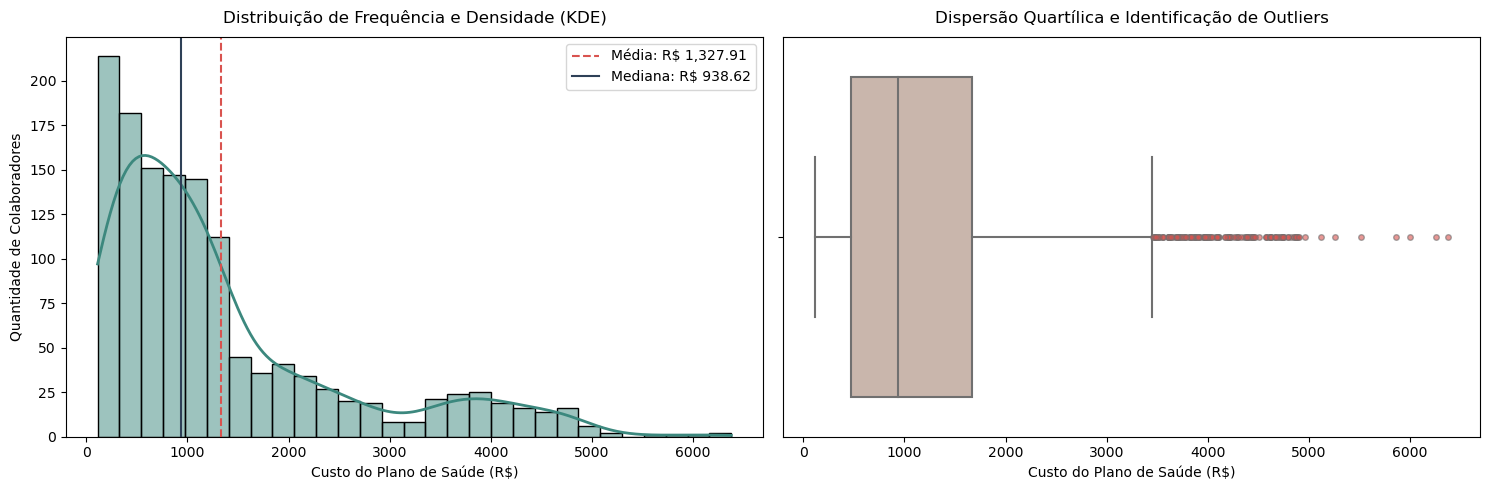

In [9]:
# ANÁLISE UNIVARIADA DA VARIÁVEL-ALVO: CUSTO_SAUDE
# Diagnóstico de distribuição de frequência, densidade contínua (KDE) e dispersão

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histograma e Curva de Densidade de Probabilidade (KDE)

sns.histplot(
    data=df,
    x='Custo_Saude',
    kde=True,
    ax=axes[0],
    color='#3C887E',
    line_kws={'linewidth': 2}
)

# Inclusão de linhas verticais para contraste entre Média e Mediana
media_custo = df['Custo_Saude'].mean()
mediana_custo = df['Custo_Saude'].median()

axes[0].axvline(media_custo, color='#D9534F', linestyle='--', linewidth=1.5, label=f'Média: R$ {media_custo:,.2f}')
axes[0].axvline(mediana_custo, color='#2E4057', linestyle='-', linewidth=1.5, label=f'Mediana: R$ {mediana_custo:,.2f}')

axes[0].set_title('Distribuição de Frequência e Densidade (KDE)', fontsize=12, pad=10)
axes[0].set_xlabel('Custo do Plano de Saúde (R$)', fontsize=10)
axes[0].set_ylabel('Quantidade de Colaboradores', fontsize=10)
axes[0].legend(frameon=True, facecolor='white', loc='upper right')


# Diagrama de Caixa (Boxplot) para Detecção de Outliers e Separação por Quartis
sns.boxplot(
    data=df,
    x='Custo_Saude',
    ax=axes[1],
    color='#CEB5A7',
    flierprops={'marker': 'o', 'markersize': 4, 'markerfacecolor': '#D9534F', 'alpha': 0.6}
)

axes[1].set_title('Dispersão Quartílica e Identificação de Outliers', fontsize=12, pad=10)
axes[1].set_xlabel('Custo do Plano de Saúde (R$)', fontsize=10)

plt.tight_layout()
plt.show()

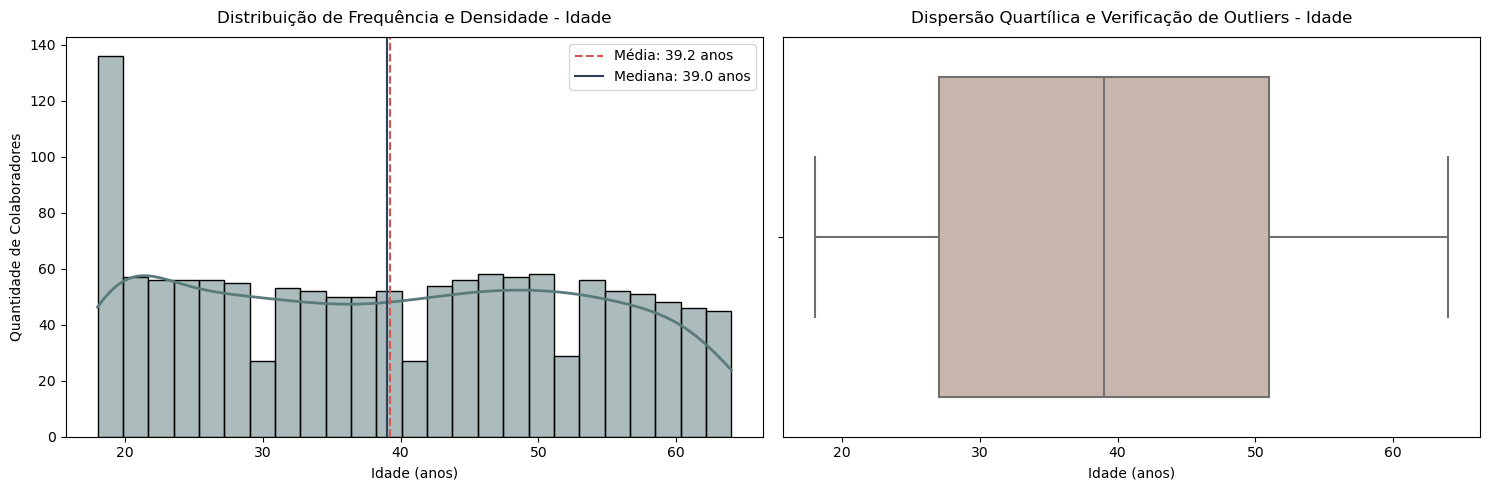

In [10]:
# ANÁLISE UNIVARIADA DA VARIÁVEL: IDADE
# Diagnóstico de frequência etária, densidade contínua (KDE) e dispersão quartílica

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histograma e Curva de Densidade de Probabilidade (KDE)

# Definimos correspondentes à amplitude dos dados (18 a 64 anos)
sns.histplot(
    data=df,
    x='Idade',
    kde=True,
    bins=25,
    ax=axes[0],
    color='#5B7B7A',
    edgecolor='black',
    line_kws={'linewidth': 2}
)

# Cálculo de parâmetros de tendência central para conferência de simetria
media_idade = df['Idade'].mean()
mediana_idade = df['Idade'].median()

axes[0].axvline(media_idade, color='#D9534F', linestyle='--', linewidth=1.5, label=f'Média: {media_idade:.1f} anos')
axes[0].axvline(mediana_idade, color='#2E4057', linestyle='-', linewidth=1.5, label=f'Mediana: {mediana_idade:.1f} anos')

axes[0].set_title('Distribuição de Frequência e Densidade - Idade', fontsize=12, pad=10)
axes[0].set_xlabel('Idade (anos)', fontsize=10)
axes[0].set_ylabel('Quantidade de Colaboradores', fontsize=10)
axes[0].legend(frameon=True, facecolor='white', loc='upper right')

# 2. Diagrama de Caixa (Boxplot) para Avaliação de Simetria e Caudas

sns.boxplot(
    data=df,
    x='Idade',
    ax=axes[1],
    color='#CEB5A7',
    flierprops={'marker': 'o', 'markersize': 5, 'markerfacecolor': '#D9534F'}
)

axes[1].set_title('Dispersão Quartílica e Verificação de Outliers - Idade', fontsize=12, pad=10)
axes[1].set_xlabel('Idade (anos)', fontsize=10)

plt.tight_layout()
plt.show()

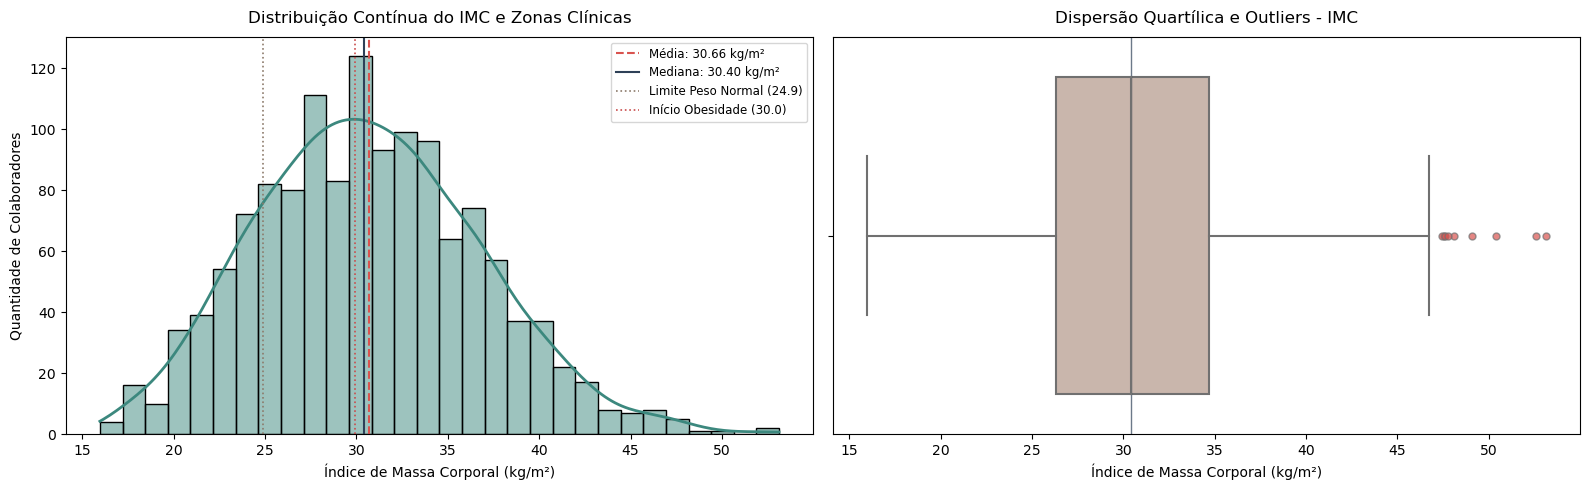

In [11]:
# ANÁLISE UNIVARIADA DA VARIÁVEL: IMC (ÍNDICE DE MASSA CORPORAL)
# Diagnóstico de densidade contínua, normalidade e dispersão com faixas clínicas

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Histograma, Densidade (KDE) e Zonas de Risco da OMS

sns.histplot(
    data=df,
    x='IMC',
    kde=True,
    bins=30,
    ax=axes[0],
    color='#3C887E',
    edgecolor='black',
    line_kws={'linewidth': 2}
)

# Parâmetros de tendência central
media_imc = df['IMC'].mean()
mediana_imc = df['IMC'].median()

axes[0].axvline(media_imc, color='#D9534F', linestyle='--', linewidth=1.5, label=f'Média: {media_imc:.2f} kg/m²')
axes[0].axvline(mediana_imc, color='#2E4057', linestyle='-', linewidth=1.5, label=f'Mediana: {mediana_imc:.2f} kg/m²')

# Linhas de corte clínicas da OMS (Sobrepeso >= 25 | Obesidade >= 30)
axes[0].axvline(24.9, color='#8C7A6B', linestyle=':', linewidth=1.2, label='Limite Peso Normal (24.9)')
axes[0].axvline(29.9, color='#C94C4C', linestyle=':', linewidth=1.2, label='Início Obesidade (30.0)')

axes[0].set_title('Distribuição Contínua do IMC e Zonas Clínicas', fontsize=12, pad=10)
axes[0].set_xlabel('Índice de Massa Corporal (kg/m²)', fontsize=10)
axes[0].set_ylabel('Quantidade de Colaboradores', fontsize=10)
axes[0].legend(frameon=True, facecolor='white', loc='upper right', fontsize=8.5)

# 2. Boxplot para Avaliação de Dispersão e Valores Extremos

sns.boxplot(
    data=df,
    x='IMC',
    ax=axes[1],
    color='#CEB5A7',
    flierprops={'marker': 'o', 'markersize': 5, 'markerfacecolor': '#D9534F', 'alpha': 0.7}
)

# Linha de referência da mediana também no boxplot
axes[1].axvline(mediana_imc, color='#2E4057', linestyle='-', linewidth=1, alpha=0.7)

axes[1].set_title('Dispersão Quartílica e Outliers - IMC', fontsize=12, pad=10)
axes[1].set_xlabel('Índice de Massa Corporal (kg/m²)', fontsize=10)

plt.tight_layout()
plt.show()

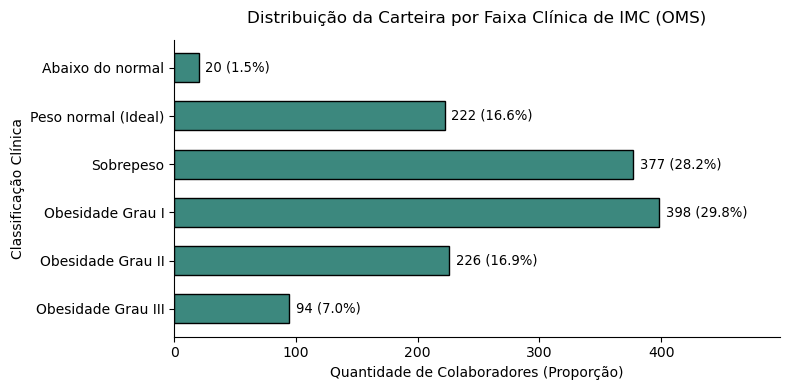

In [12]:
# DISCRETIZAÇÃO CLÍNICA DO IMC (CLASSIFICAÇÃO OMS)
# Tradução da variável contínua em grupos operacionais de saúde ocupacional

# Definição dos limites e categorias clínicas (Diretriz OMS)
limites_imc = [0, 18.5, 24.9, 29.9, 34.9, 39.9, float('inf')]
categorias_imc = [
    'Abaixo do normal', 
    'Peso normal (Ideal)', 
    'Sobrepeso', 
    'Obesidade Grau I', 
    'Obesidade Grau II', 
    'Obesidade Grau III'
]

# Criação da feature categórica ordinal no DataFrame
df['Classificacao_IMC'] = pd.cut(
    df['IMC'], 
    bins=limites_imc, 
    labels=categorias_imc, 
    right=False
)

# Cálculo de frequências absolutas e relativas
contagem_imc = df['Classificacao_IMC'].value_counts().reindex(categorias_imc, fill_value=0)
total_amostra = len(df)

# Plotagem em barras horizontais para melhor legibilidade dos rótulos
fig, ax = plt.subplots(figsize=(8, 4))

barras = ax.barh(
    contagem_imc.index, 
    contagem_imc.values, 
    color='#3C887E', 
    edgecolor='black', 
    height=0.6
)

# Inverte o eixo vertical para manter a ordem clínica do menor para o maior IMC
ax.invert_yaxis()

# Adição de rótulos contendo Quantidade Absoluta e Percentual (%)
rotulos = [f'{valor:,} ({valor / total_amostra:.1%})' for valor in contagem_imc.values]
ax.bar_label(barras, labels=rotulos, padding=5, fontsize=9.5)

# Formatação e limpeza visual (Data-Ink Ratio)
ax.set_title('Distribuição da Carteira por Faixa Clínica de IMC (OMS)', fontsize=12, pad=12)
ax.set_xlabel('Quantidade de Colaboradores (Proporção)', fontsize=10)
ax.set_ylabel('Classificação Clínica', fontsize=10)

# Ajuste de limite do eixo horizontal para o texto não colidir na borda
ax.set_xlim(0, max(contagem_imc.values) * 1.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

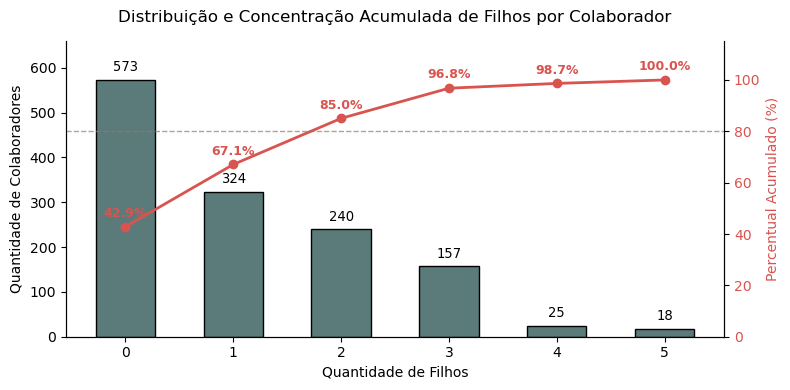

In [13]:
# ANÁLISE UNIVARIADA DA VARIÁVEL: QTE_FILHOS (COM CURVA ACUMULADA)
# Frequência simples por categoria e curva de percentual acumulado

# Contagem e ordenação numérica da quantidade de dependentes
contagem_filhos = df['Qte_Filhos'].value_counts().sort_index()
total_colaboradores = len(df)

# Cálculo do percentual acumulado
pct_acumulado = (contagem_filhos.cumsum() / total_colaboradores) * 100

# Configuração da figura e do eixo principal (barras)
fig, ax1 = plt.subplots(figsize=(8, 4))

barras = ax1.bar(
    contagem_filhos.index.astype(str),
    contagem_filhos.values,
    color='#5B7B7A',
    edgecolor='black',
    width=0.55,
    label='Colaboradores'
)

# Rótulo nas barras com a quantidade absoluta
ax1.bar_label(barras, padding=4, fontsize=9.5)

ax1.set_title('Distribuição e Concentração Acumulada de Filhos por Colaborador', fontsize=12, pad=14)
ax1.set_xlabel('Quantidade de Filhos', fontsize=10)
ax1.set_ylabel('Quantidade de Colaboradores', fontsize=10)
ax1.set_ylim(0, max(contagem_filhos.values) * 1.15)
ax1.spines['top'].set_visible(False)

# Eixo secundário para a linha de percentual acumulado
ax2 = ax1.twinx()
linha = ax2.plot(
    contagem_filhos.index.astype(str),
    pct_acumulado.values,
    color='#D9534F',
    marker='o',
    linewidth=2,
    markersize=6,
    label='% Acumulado'
)

# Formatação e rótulos de dados na linha acumulada
for i, valor in enumerate(pct_acumulado.values):
    ax2.annotate(
        f'{valor:.1f}%',
        (i, valor),
        textcoords="offset points",
        xytext=(0, 7),
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='#D9534F'
    )

ax2.set_ylabel('Percentual Acumulado (%)', fontsize=10, color='#D9534F')
ax2.tick_params(axis='y', labelcolor='#D9534F')
ax2.set_ylim(0, 115)
ax2.spines['top'].set_visible(False)

# Linha de referência no patamar clássico de 80%
ax2.axhline(80, color='#8C7A6B', linestyle='--', linewidth=1, alpha=0.7)

plt.tight_layout()
plt.show()

### Análise Univariada: Variáveis Categóricas

In [14]:
# VALORES DISTINTOS DAS VARIÁVEIS CATEGÓRICAS

colunas_categoricas = ['Sexo', 'Fumante', 'Região']

resumo_valores_distintos = pd.DataFrame({
    'Variável': colunas_categoricas,
    'Qtd Valores Distintos': [df[col].nunique() for col in colunas_categoricas],
    'Valores Distintos': [df[col].unique().tolist() for col in colunas_categoricas]
})

resumo_valores_distintos

,Variável,Qtd Valores Distintos,Valores Distintos
0,Sexo,2,"[Feminino, Masculino]"
1,Fumante,2,"[Sim, Não]"
2,Região,4,"[Centro, Sudeste, Norte, Nordeste]"


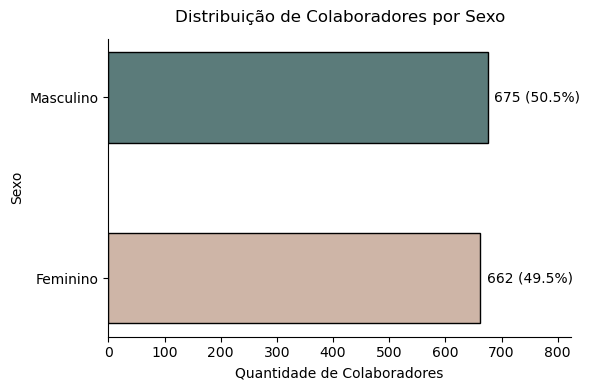

In [15]:
# ANÁLISE UNIVARIADA DA VARIÁVEL: SEXO
# Distribuição de frequência absoluta e proporção percentual

# Contagem dos valores
contagem_sexo = df['Sexo'].value_counts()
total_colaboradores = len(df)

# Configuração do gráfico em barras horizontais
fig, ax = plt.subplots(figsize=(6, 4))

barras = ax.barh(
    contagem_sexo.index,
    contagem_sexo.values,
    color=['#5B7B7A', '#CEB5A7'],
    edgecolor='black',
    height=0.5
)

# Inverte o eixo Y para a primeira categoria ficar no topo
ax.invert_yaxis()

# Rótulos nas barras com Quantidade Absoluta e Proporção (%)
rotulos = [f'{valor} ({valor / total_colaboradores:.1%})' for valor in contagem_sexo.values]
ax.bar_label(barras, labels=rotulos, padding=5, fontsize=10)

# Título e eixos
ax.set_title('Distribuição de Colaboradores por Sexo', fontsize=12, pad=12)
ax.set_xlabel('Quantidade de Colaboradores', fontsize=10)
ax.set_ylabel('Sexo', fontsize=10)

# Ajustes visuais
ax.set_xlim(0, max(contagem_sexo.values) * 1.22)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

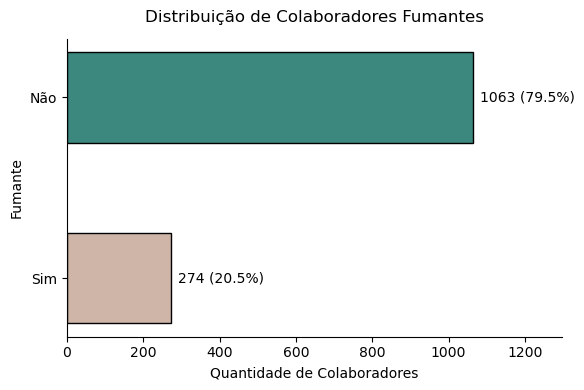

In [16]:
# ANÁLISE UNIVARIADA DA VARIÁVEL: FUMANTE
# Distribuição de frequência absoluta e proporção percentual da carteira

# Contagem dos valores
contagem_fumante = df['Fumante'].value_counts()
total_colaboradores = len(df)

# Configuração do gráfico em barras horizontais
fig, ax = plt.subplots(figsize=(6, 4))

# Cores das barras
barras = ax.barh(
    contagem_fumante.index,
    contagem_fumante.values,
    color=['#3C887E', '#CEB5A7'],
    edgecolor='black',
    height=0.5
)

# Inverte o eixo Y para a categoria mais frequente ficar no topo
ax.invert_yaxis()

# Rótulos nas barras com Quantidade Absoluta e Proporção (%)
rotulos = [f'{valor} ({valor / total_colaboradores:.1%})' for valor in contagem_fumante.values]
ax.bar_label(barras, labels=rotulos, padding=5, fontsize=10)

# Título e eixos
ax.set_title('Distribuição de Colaboradores Fumantes', fontsize=12, pad=12)
ax.set_xlabel('Quantidade de Colaboradores', fontsize=10)
ax.set_ylabel('Fumante', fontsize=10)

# Ajustes visuais
ax.set_xlim(0, max(contagem_fumante.values) * 1.22)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

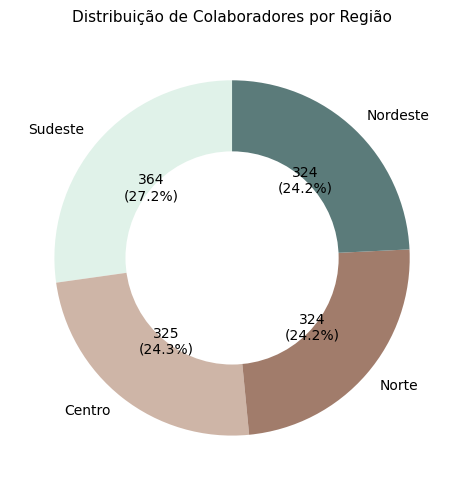

In [17]:
# ==============================================================================
# ANÁLISE UNIVARIADA DA VARIÁVEL: REGIÃO (GRÁFICO DE ROSCA)
# ==============================================================================

# Contagem dos valores da própria região
contagem_regiao = df['Região'].value_counts()
total_regiao = sum(contagem_regiao)

# Função corrigida com o total correto de região
def exibe_valores(pct):
    quantidade = int(round(pct * total_regiao / 100.0))
    return f'{quantidade}\n({pct:.1f}%)'

# Tamanho da figura
fig, ax = plt.subplots(figsize=(5.0, 5.0))

# Plota o gráfico no ax
contagem_regiao.plot(
    kind='pie',
    ax=ax,
    autopct=exibe_valores,
    startangle=90,
    colors=['#E0F2E9', '#CEB5A7', '#A17C6B', '#5B7B7A'],
    ylabel=''
)

# Círculo branco central para efeito de rosca
circulo_central = plt.Circle((0, 0), 0.60, fc='white')
ax.add_artist(circulo_central)

# Título e exibição
plt.title('Distribuição de Colaboradores por Região', fontsize=11, pad=10)
plt.tight_layout()
plt.show()

### Análise Bivariada Descritiva

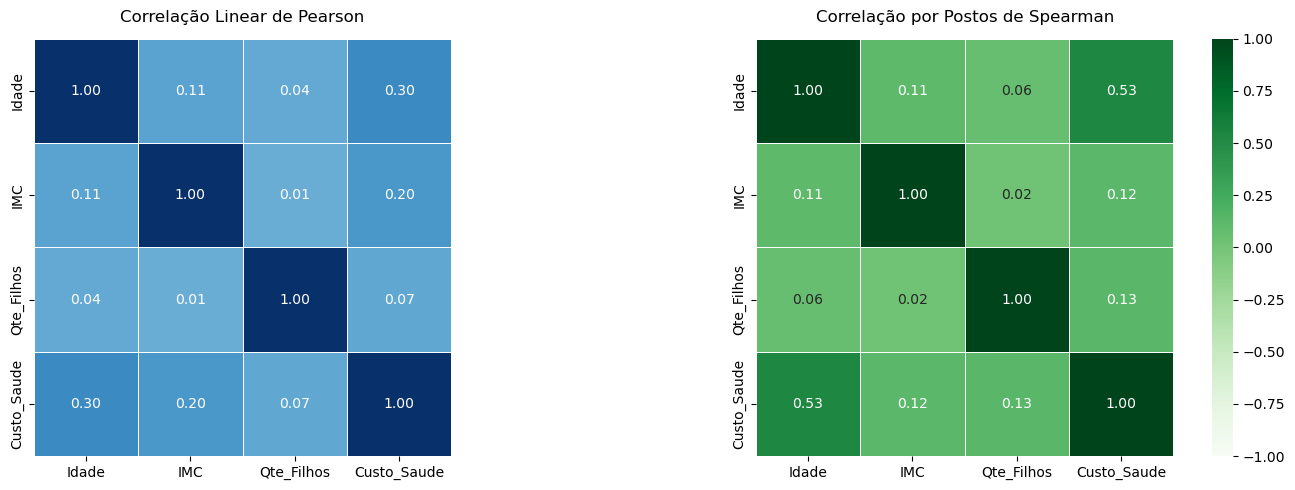

In [18]:
# ANÁLISE BIVARIADA: MATRIZES DE CORRELAÇÃO LINEAR E NÃO PARAMÉTRICA
# Comparação entre Pearson e Spearman

colunas_numericas = ['Idade', 'IMC', 'Qte_Filhos', 'Custo_Saude']

# Cálculo das matrizes de correlação
corr_pearson = df[colunas_numericas].corr(method='pearson')
corr_spearman = df[colunas_numericas].corr(method='spearman')

# Configuração do painel visual lado a lado
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Painel 1: Pearson

sns.heatmap(
    corr_pearson,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    vmin=-1,
    vmax=1,
    cbar=False,
    ax=axes[0],
    linewidths=0.5,
    square=True
)
axes[0].set_title('Correlação Linear de Pearson', fontsize=12, pad=12)

# Painel 2: Spearman

sns.heatmap(
    corr_spearman,
    annot=True,
    fmt='.2f',
    cmap='Greens',
    vmin=-1,
    vmax=1,
    cbar=True,
    ax=axes[1],
    linewidths=0.5,
    square=True
)
axes[1].set_title('Correlação por Postos de Spearman', fontsize=12, pad=12)

plt.tight_layout()
plt.show()

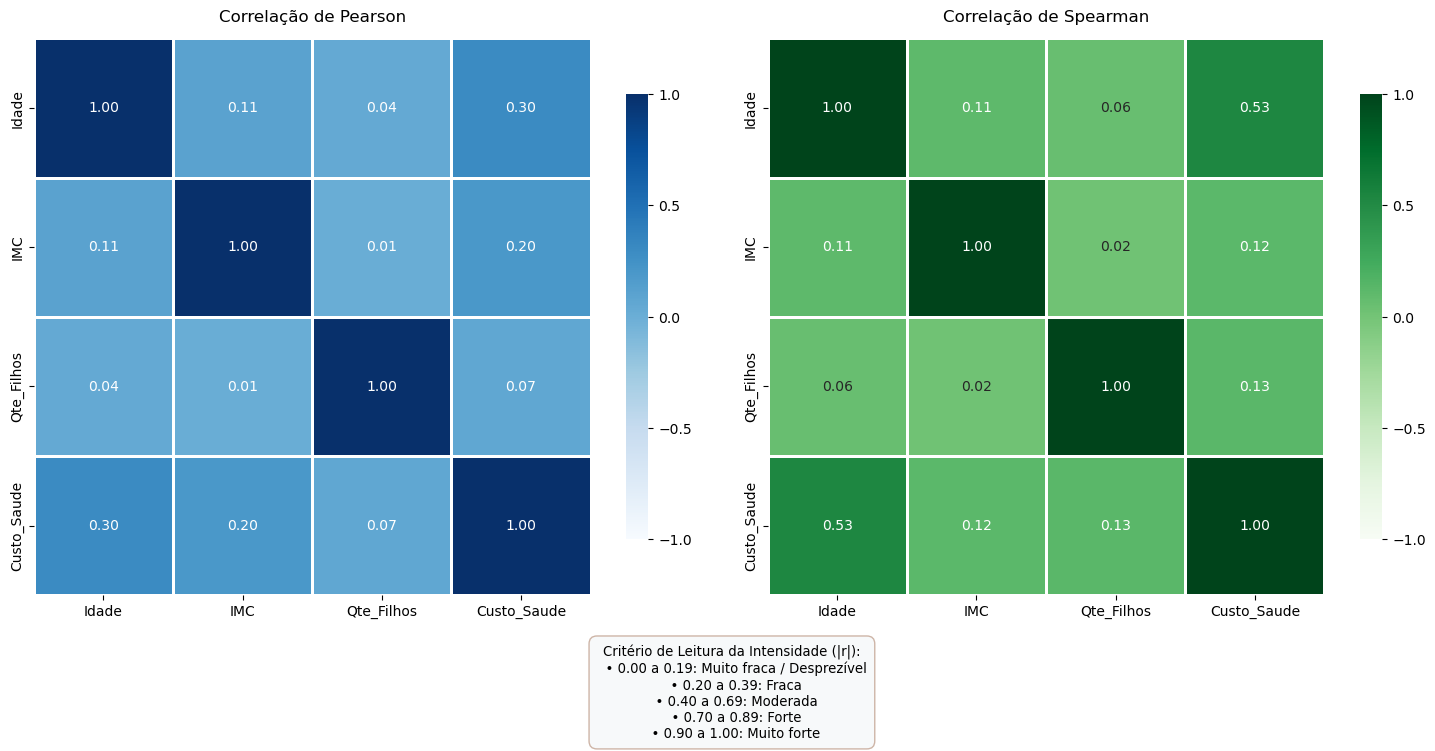

In [19]:
# ANÁLISE BIVARIADA: MATRIZES DE CORRELAÇÃO (PEARSON E SPEARMAN)
# Avaliação de associação linear e monotônica entre as variáveis numéricas

colunas_numericas = ['Idade', 'IMC', 'Qte_Filhos', 'Custo_Saude']

# Cálculo das matrizes
corr_pearson = df[colunas_numericas].corr(method='pearson')
corr_spearman = df[colunas_numericas].corr(method='spearman')

# Configuração dos painéis lado a lado
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Parâmetros comuns para as barras de cores laterais
cbar_kws = {'shrink': 0.8, 'ticks': [-1, -0.5, 0, 0.5, 1]}

# Painel 1: Pearson (Linear)

sns.heatmap(
    corr_pearson,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    vmin=-1,
    vmax=1,
    cbar=True,
    cbar_kws=cbar_kws,
    ax=axes[0],
    linewidths=0.8,
    linecolor='white',
    square=True
)
axes[0].set_title('Correlação de Pearson', fontsize=12, pad=12)

# Painel 2: Spearman (Monotônica / Postos)

sns.heatmap(
    corr_spearman,
    annot=True,
    fmt='.2f',
    cmap='Greens',
    vmin=-1,
    vmax=1,
    cbar=True,
    cbar_kws=cbar_kws,
    ax=axes[1],
    linewidths=0.8,
    linecolor='white',
    square=True
)
axes[1].set_title('Correlação de Spearman', fontsize=12, pad=12)

# Legenda Interpretativa dos Coeficientes (Convenção Estatística)

texto_legenda = (
    "Critério de Leitura da Intensidade (|r|):\n"
    "  • 0.00 a 0.19: Muito fraca / Desprezível\n"
    "  • 0.20 a 0.39: Fraca\n"
    "  • 0.40 a 0.69: Moderada\n"
    "  • 0.70 a 0.89: Forte\n"
    "  • 0.90 a 1.00: Muito forte"
)

fig.text(
    0.5, -0.05,
    texto_legenda,
    ha='center',
    va='top',
    fontsize=9.5,
    bbox=dict(boxstyle='round,pad=0.6', facecolor='#F7F9FA', edgecolor='#CEB5A7', linewidth=1)
)

plt.tight_layout()
plt.show()

In [20]:
# SUMARIZAÇÃO ESTATÍSTICA BIVARIADA: CUSTO_SAUDE POR GRUPO
# Métricas de tendência central, dispersão e quartis por segmento

def sumarizar_custo(dataframe, coluna_grupo):
    resumo = dataframe.groupby(coluna_grupo, observed=False)['Custo_Saude'].agg(
        Contagem='count',
        Media='mean',
        Mediana='median',
        Desvio_Padrao='std',
        Q1=lambda x: x.quantile(0.25),
        Q3=lambda x: x.quantile(0.75)
    ).reset_index()
    
    # Cálculo do Intervalo Interquartil (IQR)
    resumo['IQR'] = resumo['Q3'] - resumo['Q1']
    
    # Adiciona a identificação da variável analisada
    resumo.insert(0, 'Variavel', coluna_grupo)
    resumo.rename(columns={coluna_grupo: 'Categoria'}, inplace=True)
    return resumo

# Lista de variáveis categóricas e discretas
grupos = ['Fumante', 'Classificacao_IMC', 'Sexo', 'Região', 'Qte_Filhos']

# Consolida todas as tabelas em um único DataFrame formatado
tabela_bivariada = pd.concat([sumarizar_custo(df, g) for g in grupos], ignore_index=True)

# Formatação monetária para exibição executiva
tabela_bivariada_formatada = tabela_bivariada.copy()
colunas_moeda = ['Media', 'Mediana', 'Desvio_Padrao', 'Q1', 'Q3', 'IQR']
for col in colunas_moeda:
    tabela_bivariada_formatada[col] = tabela_bivariada_formatada[col].map(lambda x: f"R$ {x:,.2f}")

tabela_bivariada_formatada

,Variavel,Categoria,Contagem,Media,Mediana,Desvio_Padrao,Q1,Q3,IQR
0,Fumante,Não,1063,R$ 844.07,R$ 734.57,R$ 599.30,R$ 398.89,"R$ 1,136.30",R$ 737.41
1,Fumante,Sim,274,"R$ 3,205.02","R$ 3,445.63","R$ 1,154.15","R$ 2,082.62","R$ 4,101.92","R$ 2,019.30"
2,Classificacao_IMC,Abaixo do normal,20,R$ 885.22,R$ 675.93,R$ 773.50,R$ 275.16,"R$ 1,292.32","R$ 1,017.15"
3,Classificacao_IMC,Peso normal (Ideal),222,"R$ 1,037.95",R$ 860.42,R$ 750.07,R$ 405.77,"R$ 1,519.73","R$ 1,113.96"
4,Classificacao_IMC,Sobrepeso,377,"R$ 1,103.03",R$ 870.35,R$ 803.05,R$ 468.78,"R$ 1,582.88","R$ 1,114.10"
5,Classificacao_IMC,Obesidade Grau I,398,"R$ 1,415.10",R$ 939.45,"R$ 1,333.10",R$ 477.27,"R$ 1,595.49","R$ 1,118.22"
6,Classificacao_IMC,Obesidade Grau II,226,"R$ 1,718.64","R$ 1,131.36","R$ 1,525.01",R$ 597.67,"R$ 2,820.12","R$ 2,222.46"
7,Classificacao_IMC,Obesidade Grau III,94,"R$ 1,700.28",R$ 977.49,"R$ 1,672.68",R$ 549.46,"R$ 2,334.78","R$ 1,785.31"
8,Sexo,Feminino,662,"R$ 1,256.96",R$ 941.30,"R$ 1,112.87",R$ 488.52,"R$ 1,445.47",R$ 956.95
9,Sexo,Masculino,675,"R$ 1,397.50",R$ 937.79,"R$ 1,297.20",R$ 465.40,"R$ 1,900.67","R$ 1,435.27"


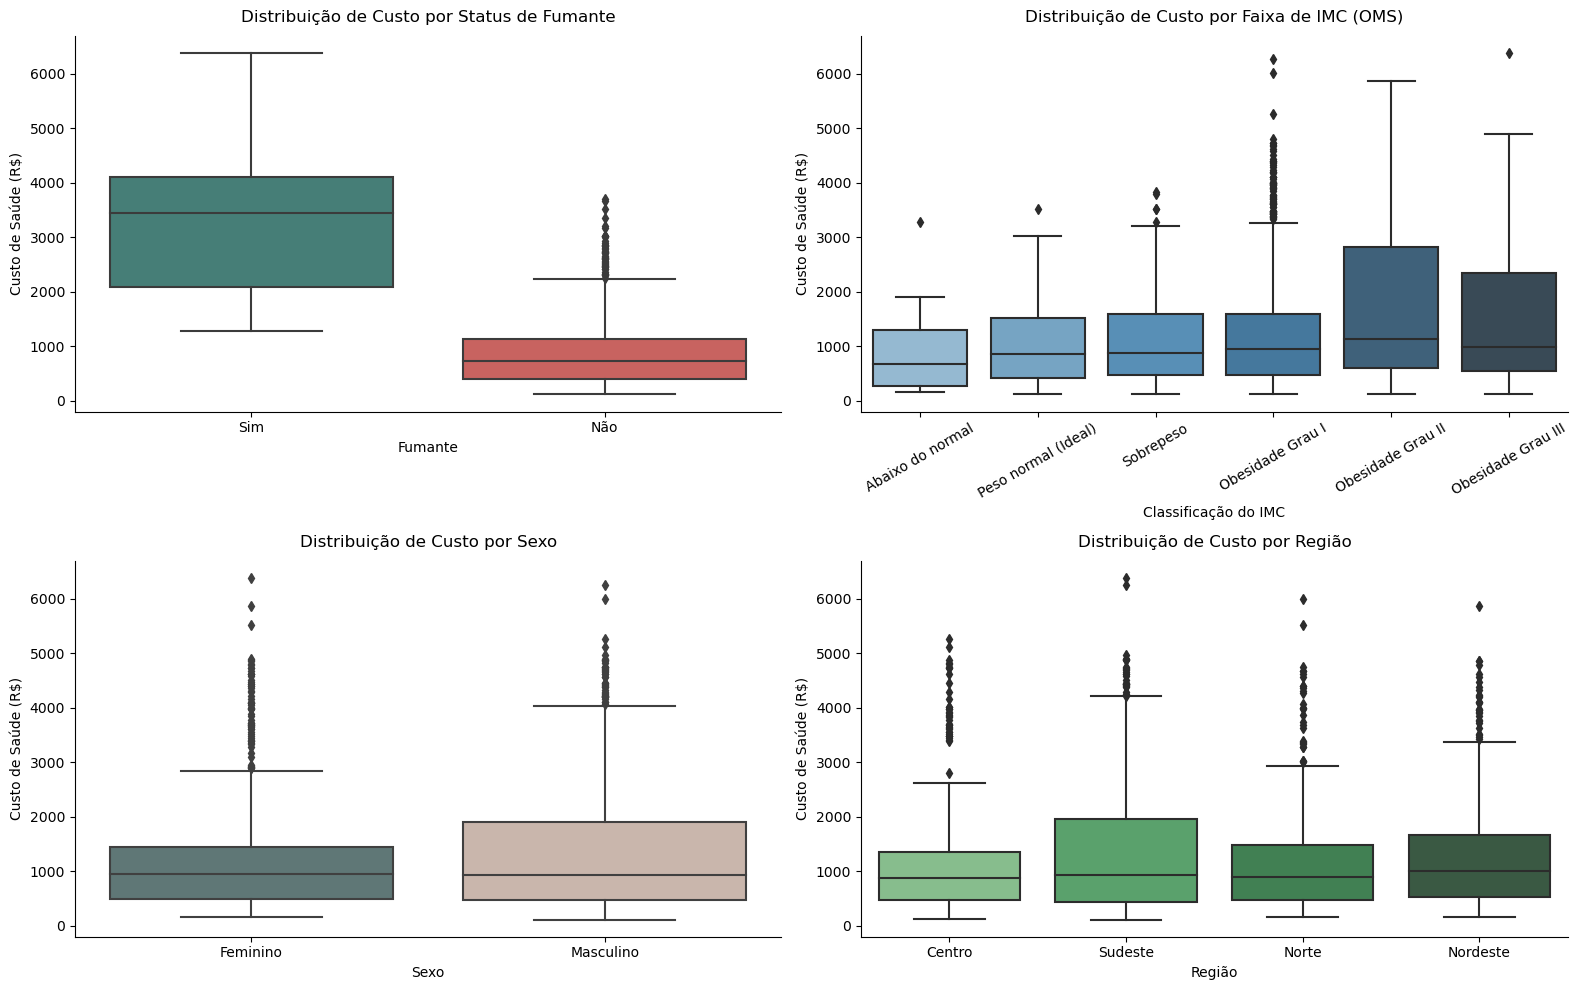

In [21]:
# VISUALIZAÇÃO DA DISPERSÃO: BOXPLOTS BIVARIADOS DE CUSTO_SAUDE
# Identificação de assimetrias, medianas e severidade de sinistros por grupo

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Painel 1: Custo por Hábito Tabágico (Fumante)

sns.boxplot(
    data=df,
    x='Fumante',
    y='Custo_Saude',
    palette=['#3C887E', '#D9534F'],
    ax=axes[0, 0]
)
axes[0, 0].set_title('Distribuição de Custo por Status de Fumante', fontsize=12, pad=10)
axes[0, 0].set_xlabel('Fumante', fontsize=10)
axes[0, 0].set_ylabel('Custo de Saúde (R$)', fontsize=10)


# Painel 2: Custo por Classificação Clínica de IMC

sns.boxplot(
    data=df,
    x='Classificacao_IMC',
    y='Custo_Saude',
    palette='Blues_d',
    ax=axes[0, 1]
)
axes[0, 1].set_title('Distribuição de Custo por Faixa de IMC (OMS)', fontsize=12, pad=10)
axes[0, 1].set_xlabel('Classificação do IMC', fontsize=10)
axes[0, 1].set_ylabel('Custo de Saúde (R$)', fontsize=10)
axes[0, 1].tick_params(axis='x', rotation=30)


# Painel 3: Custo por Sexo

sns.boxplot(
    data=df,
    x='Sexo',
    y='Custo_Saude',
    palette=['#5B7B7A', '#CEB5A7'],
    ax=axes[1, 0]
)
axes[1, 0].set_title('Distribuição de Custo por Sexo', fontsize=12, pad=10)
axes[1, 0].set_xlabel('Sexo', fontsize=10)
axes[1, 0].set_ylabel('Custo de Saúde (R$)', fontsize=10)


# Painel 4: Custo por Região

sns.boxplot(
    data=df,
    x='Região',
    y='Custo_Saude',
    palette='Greens_d',
    ax=axes[1, 1]
)
axes[1, 1].set_title('Distribuição de Custo por Região', fontsize=12, pad=10)
axes[1, 1].set_xlabel('Região', fontsize=10)
axes[1, 1].set_ylabel('Custo de Saúde (R$)', fontsize=10)

# Ajuste visual das bordas em todos os subplots
for ax in axes.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Principais Resultados da Análise Descritiva

#### 1. Perfil dos Colaboradores (Demografia e Saúde)
* **Volume e Integridade de Dados:** A base analisada contém informações de 1.337 colaboradores da empresa. Os dados apresentam-se consistentes e sem informações ausentes.
* **Perfil Demográfico:** A distribuição da amostra é bastante equilibrada, com proporções iguais entre homens e mulheres (cerca de 50% cada) e uma divisão homogênea entre as quatro regiões geográficas. A faixa etária varia de forma uniforme entre 18 e 64 anos, com metade do grupo tendo até 39 anos.
* **Perfil Clínico e Familiar:** 
  * Observa-se que mais da metade dos colaboradores da base já se encontra acima do peso ideal, enquadrando-se nas faixas de Obesidade.
  * Aproximadamente 1 a cada 5 funcionários é fumante (cerca de 20,5%).
  * O núcleo familiar é majoritariamente pequeno: 85% dos funcionários possuem no máximo 2 dependentes (sendo que 42% não possuem filhos cadastrados).

---

#### 2. Comportamento do Custo de Saúde (Variável-Alvo)
* **O Impacto de Valores Extremos:** O custo médio anual por colaborador é de 1.327 reais. No entanto, esse valor não reflete a realidade da maior parte do grupo. Metade da empresa gera um custo de saúde de no máximo 938 reais ao ano.
* **A Métrica de Referência:** A média geral financeira é fortemente puxada para cima por um grupo muito pequeno que gera gastos altíssimos (como internações ou tratamentos complexos). Logo, o custo típico de R$ 938 (a mediana) representa de forma mais realista o padrão financeiro e a sinistralidade padrão da carteira.

---

#### 3. Fatores de Impacto nos Custos (Análise por Segmento)
* **O Efeito do Tabagismo:** O hábito de fumar é o fator que apresenta o maior contraste financeiro na base. O segmento de fumantes concentra custos de saúde significativamente superiores aos não fumantes.
* **O Impacto da Obesidade:** Os custos do plano de saúde não sobem gradativamente de acordo com o ganho leve de peso. A análise revela um "salto" de custos expressivo especificamente quando os indivíduos ultrapassam a barreira e entram na faixa de Obesidade.
* **A Relação com a Idade:** Conforme o esperado no setor de saúde, o custo financeiro sobe de forma constante e natural com o avanço da idade do colaborador.
* **Fatores de Menor Impacto:** Quando analisados isoladamente, o gênero biológico, a região de moradia e a quantidade de filhos não apresentaram um impacto expressivo na elevação dos custos médicos.

In [22]:
# EXPORTAÇÃO DOS DADOS PARA O POWER BI

# Exportando em formato CSV (configurado para o padrão brasileiro)
df.to_csv('custo_saude_limpo_bi.csv', index=False, sep=';', decimal=',', encoding='utf-8-sig')

print("Arquivo 'custo_saude_limpo_bi.csv' gerado com sucesso!")

Arquivo 'custo_saude_limpo_bi.csv' gerado com sucesso!
